In [2]:
!nvidia-smi

Mon Sep 21 01:49:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!git clone https://github.com/NikitaBuchenik/hsys.git

Cloning into 'hsys'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 30 (delta 0), reused 27 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 9.29 KiB | 279.00 KiB/s, done.


In [4]:
%cd hsys

/content/hsys


In [5]:
%cd first

/content/hsys/first


In [6]:
!ls

benchmarks  CMakeLists.txt  core  README.md  scripts  tests


In [8]:
!apt-get update -qq
!apt-get install -y -qq cmake ninja-build

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package ninja-build.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../ninja-build_1.11.1-2_amd64.deb ...
Unpacking ninja-build (1.11.1-2) ...
Setting up ninja-build (1.11.1-2) ...
Processing triggers for man-db (2.12.0-4build2) ...


In [9]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Mon Sep 21 01:50:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8       

In [10]:
!cmake -S . -B build -G Ninja -DCMAKE_BUILD_TYPE=Release

-- The CXX compiler identification is GNU 13.3.0
-- The CUDA compiler identification is NVIDIA 12.8.93 with host compiler GNU 13.3.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Detecting CUDA compiler ABI info
-- Detecting CUDA compiler ABI info - done
-- Check for working CUDA compiler: /usr/local/cuda/bin/nvcc - skipped
-- Detecting CUDA compile features
-- Detecting CUDA compile features - done
-- The C compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE
CMake Deprecation Warning at build/_deps/eigen-src/CMakeLists.txt

In [13]:
!cmake --build build -j2

[31/31] Linking CXX executable benchmarks/vector_benchmark


In [14]:
!find build -maxdepth 3 -type f | sort

build/benchmarks/cmake_install.cmake
build/benchmarks/vector_benchmark
build/build.ninja
build/buildtests.sh
build/check.sh
build/CMakeCache.txt
build/CMakeFiles/3.31.10/CMakeCCompiler.cmake
build/CMakeFiles/3.31.10/CMakeCUDACompiler.cmake
build/CMakeFiles/3.31.10/CMakeCXXCompiler.cmake
build/CMakeFiles/3.31.10/CMakeDetermineCompilerABI_C.bin
build/CMakeFiles/3.31.10/CMakeDetermineCompilerABI_CUDA.bin
build/CMakeFiles/3.31.10/CMakeDetermineCompilerABI_CXX.bin
build/CMakeFiles/3.31.10/CMakeDetermineCompilerABI_Fortran.bin
build/CMakeFiles/3.31.10/CMakeFortranCompiler.cmake
build/CMakeFiles/3.31.10/CMakeSystem.cmake
build/CMakeFiles/cmake.check_cache
build/CMakeFiles/CMakeConfigureLog.yaml
build/CMakeFiles/rules.ninja
build/CMakeFiles/TargetDirectories.txt
build/CMakeFiles/vector_benchmark.dir/cmake_device_link.o
build/CMakeFiles/vector_tests.dir/cmake_device_link.o
build/cmake_install.cmake
build/core/cmake_install.cmake
build/core/libvector_cuda.a
build/CTestCustom.cmake
build/debug.sh

In [17]:
!./build/tests/vector_tests

Running main() from /content/hsys/first/build/_deps/googletest-src/googletest/src/gtest_main.cc
[==========] Running 5 tests from 3 test suites.
[----------] Global test environment set-up.
[----------] 2 tests from VectorArchitectureTest
[ RUN      ] VectorArchitectureTest.ViewIsTriviallyCopyable
[       OK ] VectorArchitectureTest.ViewIsTriviallyCopyable (0 ms)
[ RUN      ] VectorArchitectureTest.VectorCopiesShareData
[       OK ] VectorArchitectureTest.VectorCopiesShareData (281 ms)
[----------] 2 tests from VectorArchitectureTest (282 ms total)

[----------] 1 test from VectorDataTest
[ RUN      ] VectorDataTest.DataDeepCopy
[       OK ] VectorDataTest.DataDeepCopy (0 ms)
[----------] 1 test from VectorDataTest (0 ms total)

[----------] 2 tests from VectorTest
[ RUN      ] VectorTest.AdditionMatchesEigen
[       OK ] VectorTest.AdditionMatchesEigen (1 ms)
[ RUN      ] VectorTest.MismatchedSizesThrow
[       OK ] VectorTest.MismatchedSizesThrow (0 ms)
[----------] 2 tests from Vect

In [19]:
!./build/benchmarks/vector_benchmark

2026-09-21T02:34:54+00:00
Running ./build/benchmarks/vector_benchmark
Run on (2 X 2000.2 MHz CPU s)
CPU Caches:
  L1 Data 32 KiB (x1)
  L1 Instruction 32 KiB (x1)
  L2 Unified 1024 KiB (x1)
  L3 Unified 39424 KiB (x1)
Load Average: 0.20, 0.22, 0.19
------------------------------------------------------------------------------------------------
Benchmark                                      Time             CPU   Iterations UserCounters...
------------------------------------------------------------------------------------------------
BM_CudaVectorAdd/8/manual_time              4775 ns        11803 ns       167739 bytes_per_second=19.1724Mi/s
BM_CudaVectorAdd/64/manual_time             5095 ns        12245 ns       130695 bytes_per_second=143.762Mi/s
BM_CudaVectorAdd/512/manual_time            4106 ns        10623 ns       170424 bytes_per_second=1.39358Gi/s
BM_CudaVectorAdd/4096/manual_time           4194 ns        10814 ns       168531 bytes_per_second=10.9143Gi/s
BM_CudaVectorAdd/327

In [24]:
!cmake --build build -j2



[1/3] Building CUDA object benchmarks/CMakeFiles/vector_benchmark.dir/src/vector_benchmark.cu.o
/content/hsys/first/build/_deps/eigen-src/Eigen/src/Core/DenseStorage.h(223): warning #20012-D: __host__ annotation is ignored on a function("DenseStorage") that is explicitly defaulted on its first declaration
      __attribute__((host)) __attribute__((device)) DenseStorage(const DenseStorage&) = default;
                     ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/content/hsys/first/build/_deps/eigen-src/Eigen/src/Core/DenseStorage.h(223): warning #20012-D: __device__ annotation is ignored on a function("DenseStorage") that is explicitly defaulted on its first declaration
      __attribute__((host)) __attribute__((device)) DenseStorage(const DenseStorage&) = default;
                                           ^

/content/hsys/first/build/_deps/eigen-src/Eigen/src/Core/DenseStorage.h(233): warning #20012-D: __host__ annotation is ignored on a funct

In [25]:
!./build/benchmarks/vector_benchmark --benchmark_out=results.json --benchmark_out_format=json


2026-09-21T02:47:52+00:00
Running ./build/benchmarks/vector_benchmark
Run on (2 X 2000.2 MHz CPU s)
CPU Caches:
  L1 Data 32 KiB (x1)
  L1 Instruction 32 KiB (x1)
  L2 Unified 1024 KiB (x1)
  L3 Unified 39424 KiB (x1)
Load Average: 0.22, 0.27, 0.22
------------------------------------------------------------------------------------------------
Benchmark                                      Time             CPU   Iterations UserCounters...
------------------------------------------------------------------------------------------------
BM_CudaVectorAdd/8/manual_time              5684 ns        13232 ns       110924 bytes_per_second=16.1076Mi/s
BM_CudaVectorAdd/64/manual_time             4608 ns        11442 ns       128258 bytes_per_second=158.935Mi/s
BM_CudaVectorAdd/512/manual_time            4160 ns        10808 ns       167973 bytes_per_second=1.37541Gi/s
BM_CudaVectorAdd/4096/manual_time           4079 ns        10638 ns       170309 bytes_per_second=11.2227Gi/s
BM_CudaVectorAdd/327

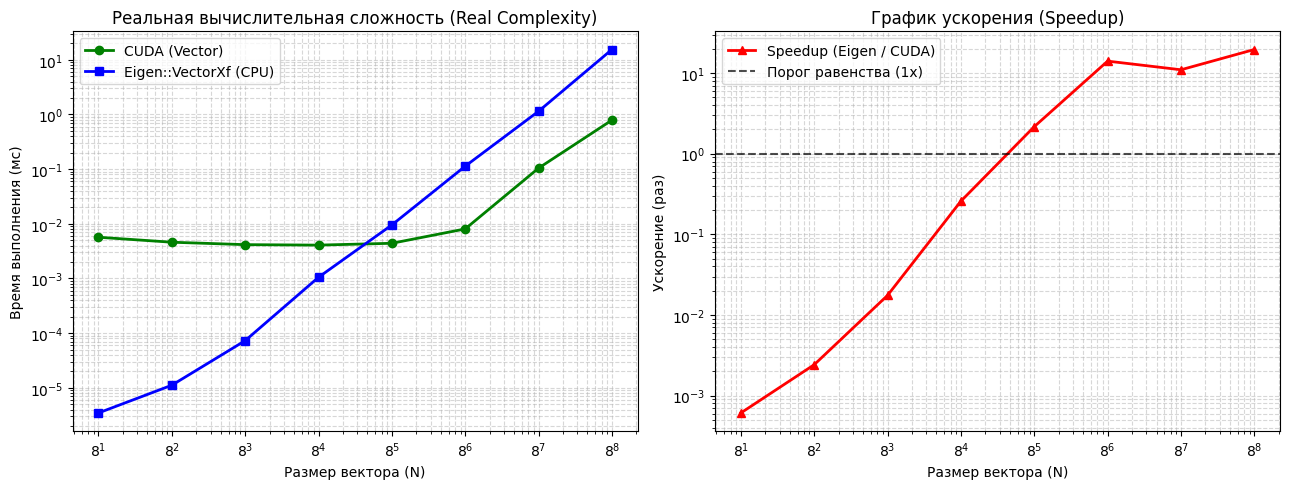

Максимальное ускорение на GPU: 19.57x (при N = 16777216)


In [27]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('results.json') as f:
    data = json.load(f)

sizes = []
cuda_times = []
eigen_times = []

for bench in data['benchmarks']:
    name = bench['name']

    if 'args' in bench and len(bench['args']) > 0:
        size = bench['args'][0]
    else:
        size = int(name.split('/')[-2] if '/manual_time' in name else name.split('/')[-1])

    time_ns = bench['real_time']

    if "BM_CudaVectorAdd" in name:
        sizes.append(size)
        cuda_times.append(time_ns)
    elif "BM_EigenVectorAdd" in name:
        eigen_times.append(time_ns)

sizes = sorted(list(set(sizes)))

cuda_ms = np.array(cuda_times) / 1e6
eigen_ms = np.array(eigen_times) / 1e6
speedup = eigen_ms / cuda_ms

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(sizes, cuda_ms, label='CUDA (Vector)', marker='o', color='green', linewidth=2)
plt.plot(sizes, eigen_ms, label='Eigen::VectorXf (CPU)', marker='s', color='blue', linewidth=2)
plt.xscale('log', base=8)
plt.yscale('log')
plt.xlabel('Размер вектора (N)')
plt.ylabel('Время выполнения (мс)')
plt.title('Реальная вычислительная сложность (Real Complexity)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(sizes, speedup, label='Speedup (Eigen / CUDA)', marker='^', color='red', linewidth=2)
plt.xscale('log', base=8)
plt.yscale('log', base=10)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.7, label='Порог равенства (1x)')
plt.xlabel('Размер вектора (N)')
plt.ylabel('Ускорение (раз)')
plt.title('График ускорения (Speedup)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Максимальное ускорение на GPU: {speedup[-1]:.2f}x (при N = {sizes[-1]})")
